In [1]:
#loading dataset
import pandas as pd

df = pd.read_csv("/content/soil_data_pre.csv")

X = df.drop("label", axis=1)
y = df["label"]

df.shape
df["label"].value_counts()

,count
label,
Banana,250
Coffee,250
Ginger,250
Pepper,250
Tapioca,250


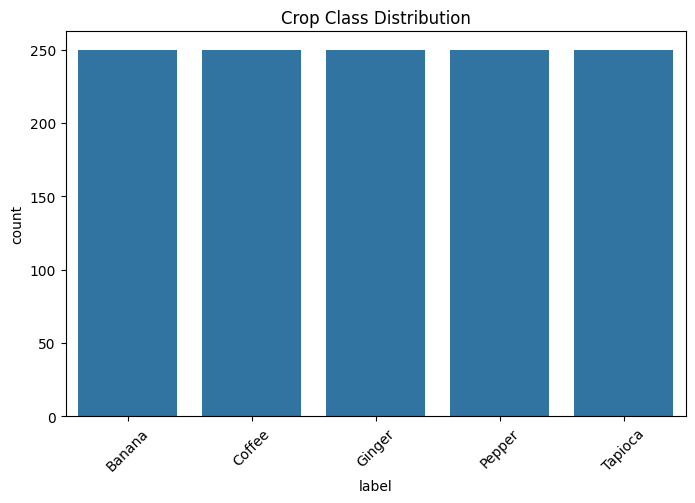

In [2]:
#Exploratory Data Analysis (EDA)
#Class Distribution

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x="label", data=df)
plt.title("Crop Class Distribution")
plt.xticks(rotation=45)
plt.show()

#Explain imbalance (mild).

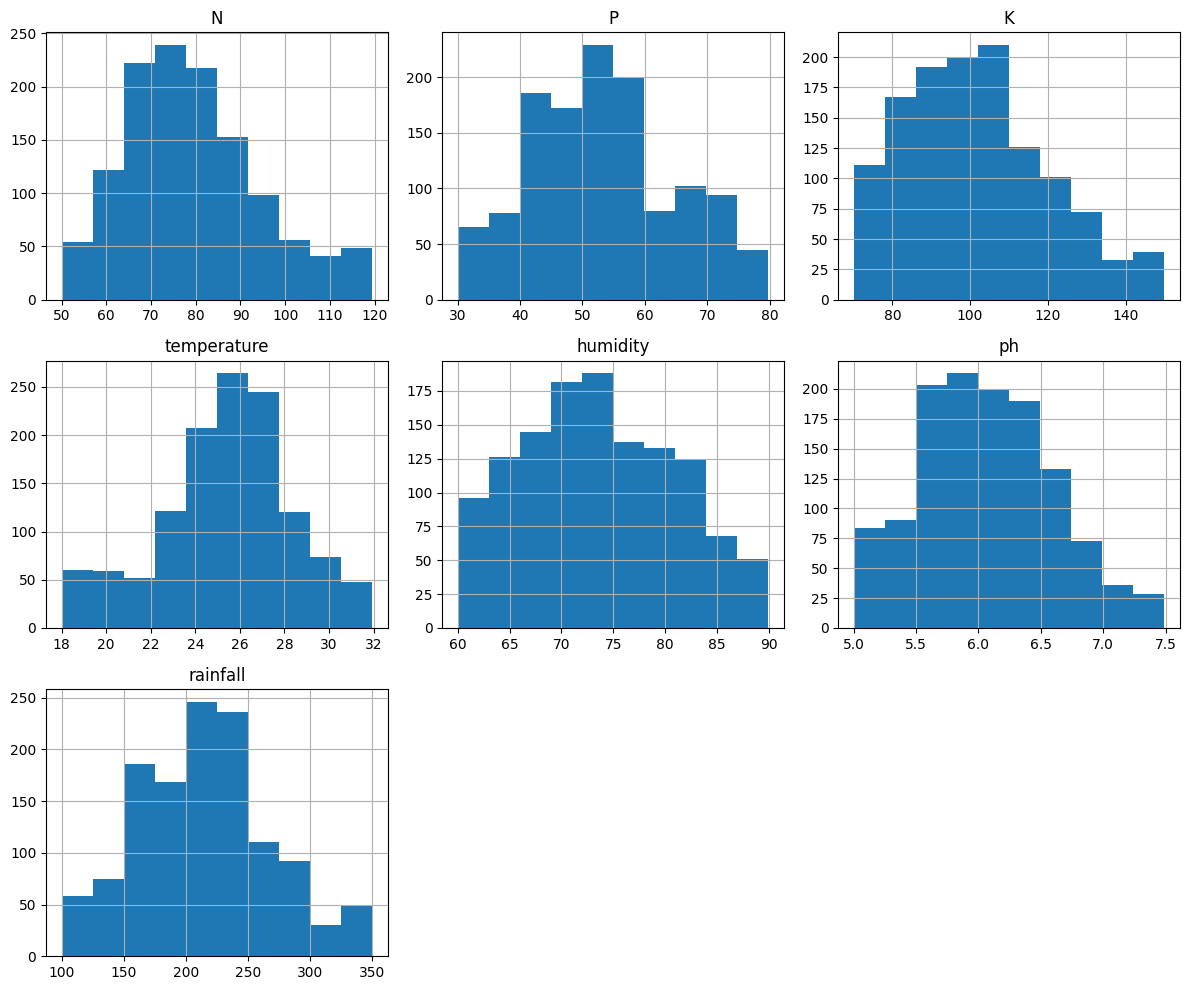

In [3]:
#Feature Distribution (histograms)

df.drop("label", axis=1).hist(figsize=(12,10))
plt.tight_layout()
plt.show()
#Explain ranges

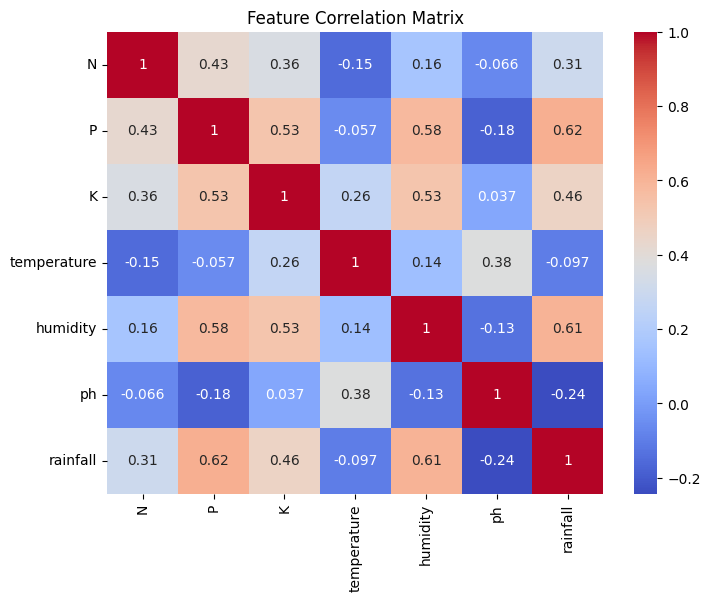

In [5]:
#Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.drop("label", axis=1).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

#Explain relationships between soil features.

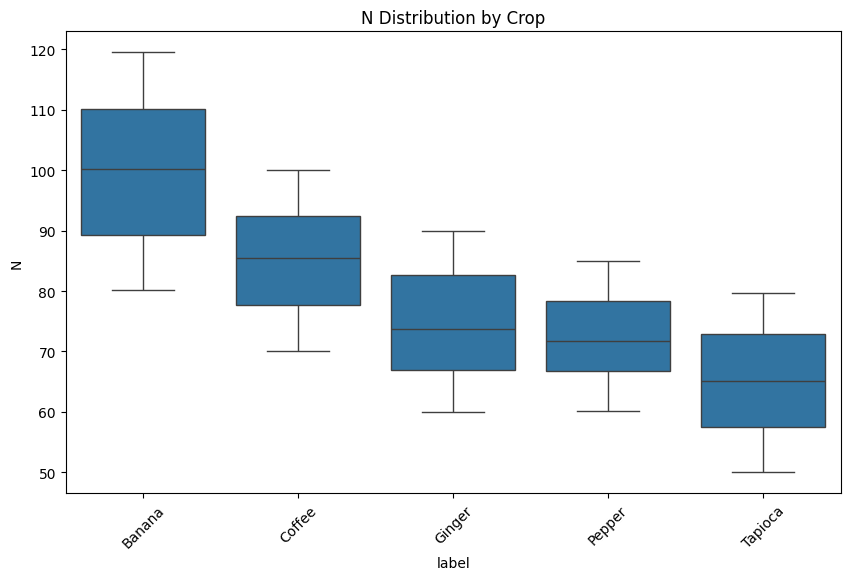

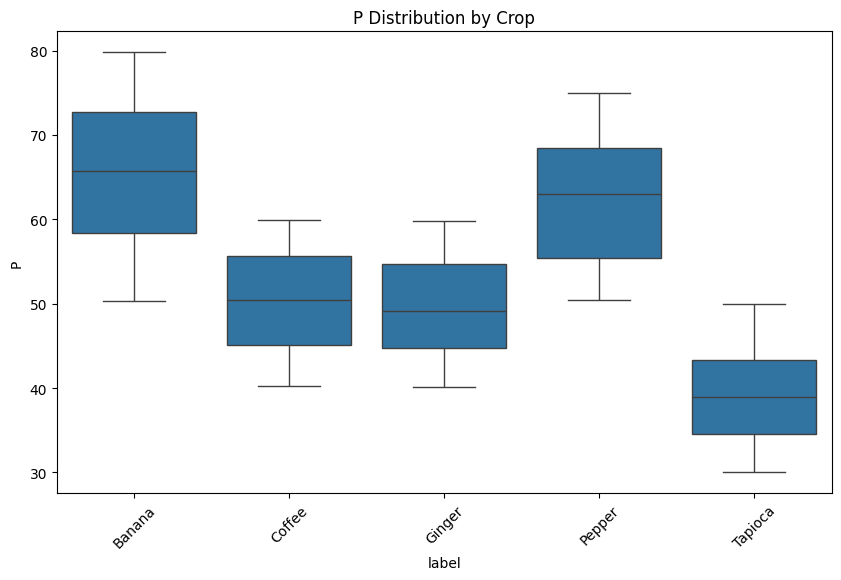

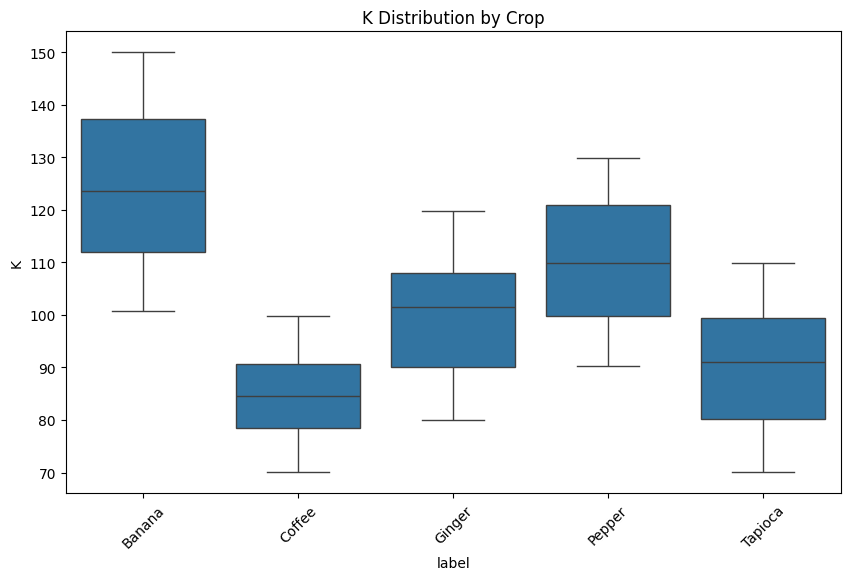

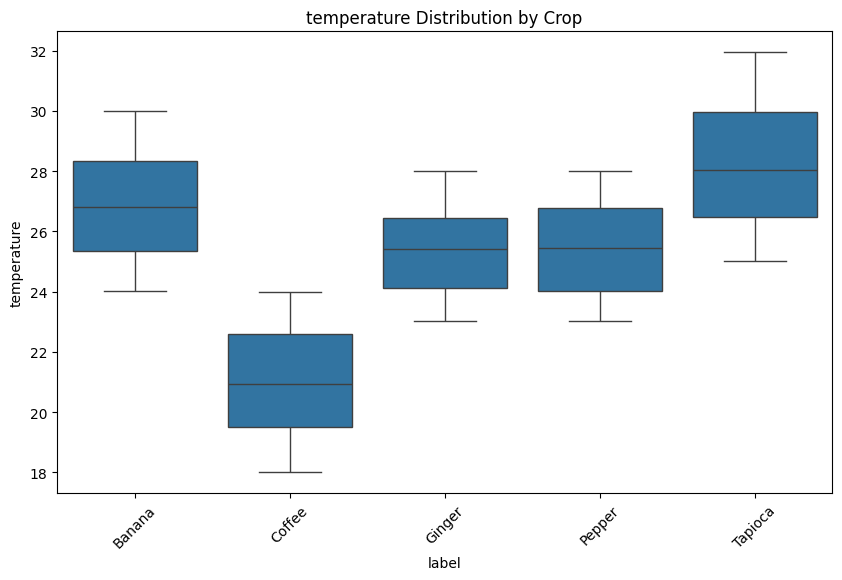

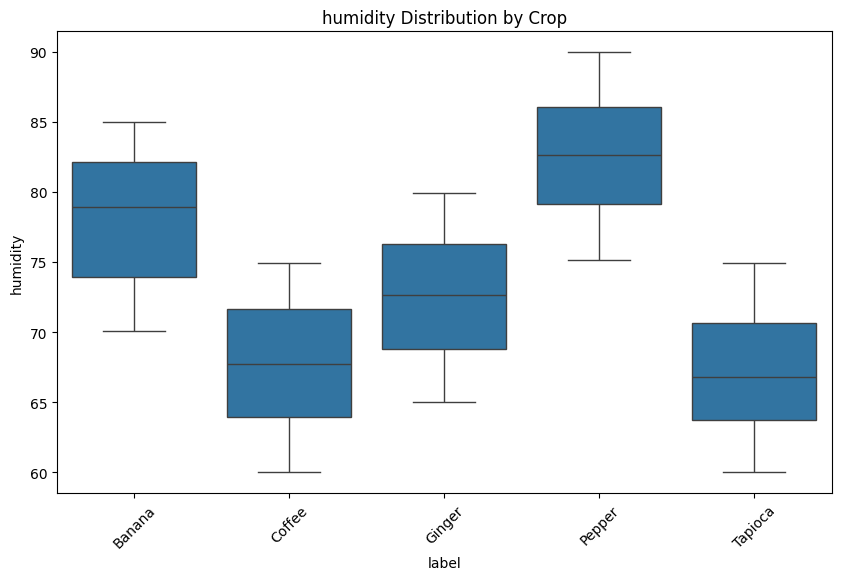

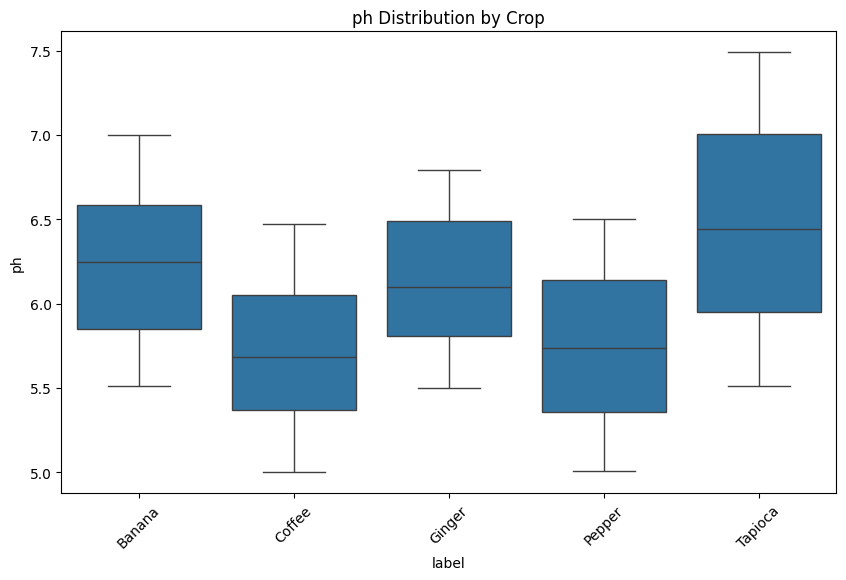

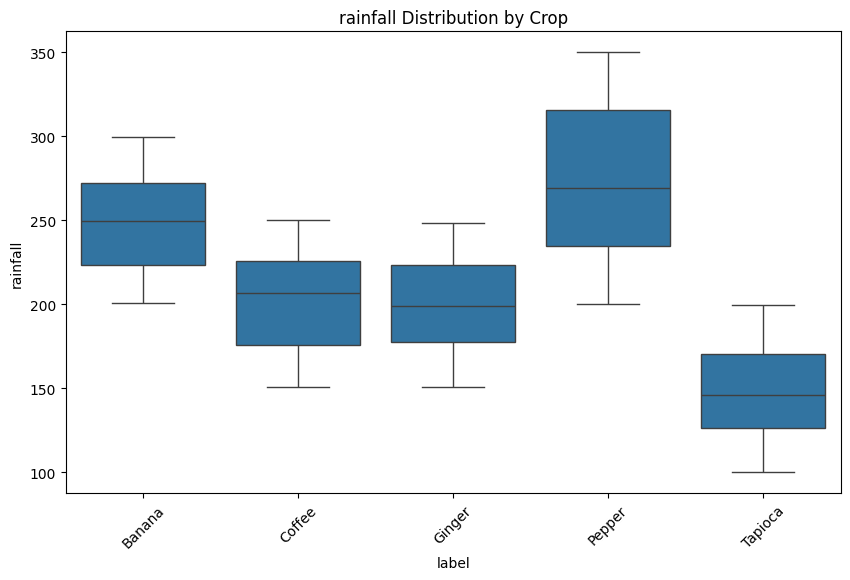

In [6]:
#Boxplots by Crop

features = df.drop("label", axis=1).columns

for feature in features:
    plt.figure(figsize=(10,6))
    sns.boxplot(x="label", y=feature, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{feature} Distribution by Crop")
    plt.show()

#Boxplots by Crop

In [ ]:
#Model Development

In [7]:
#train-test split

from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
#Train Multiple Models and test

#Logistic Regression
#KNN
#Decision Tree
#Random Forest
#SVM
#Gradient Boosting

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append((name, acc))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy
3,Random Forest,0.976
5,Gradient Boosting,0.960
2,Decision Tree,0.908
1,KNN,0.880
4,SVM,0.856
0,Logistic Regression,0.832


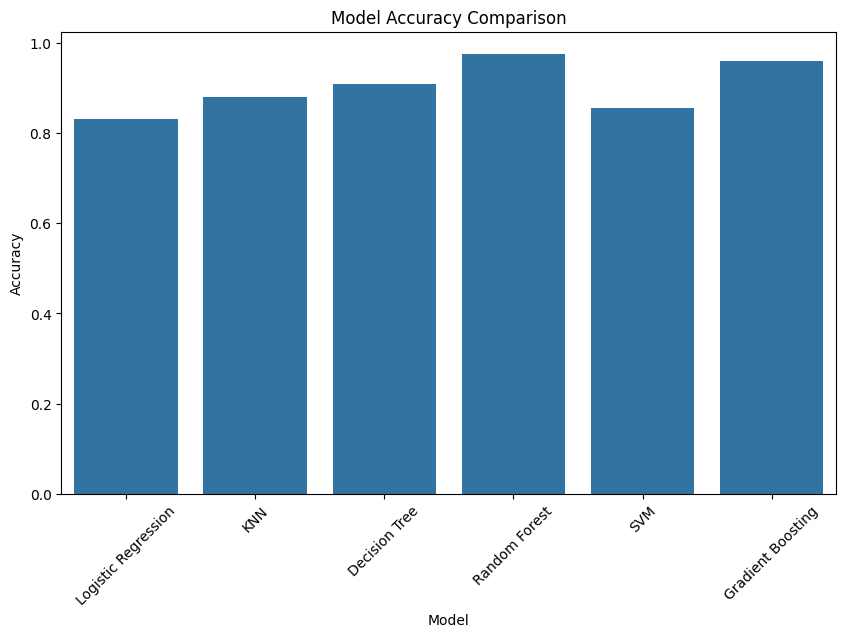

In [9]:
#Model Accuracy Comparison Visualization

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()

In [11]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=500, random_state=42)

scores = cross_val_score(rf, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())

# The import statement was duplicated and uncommenting the first one resolves the NameError.
# The second block of code was a duplicate and has been removed for clarity.

#Explain stability of model.

Cross-validation scores: [0.964 0.952 0.968 0.972 0.94 ]
Mean CV accuracy: 0.9591999999999998


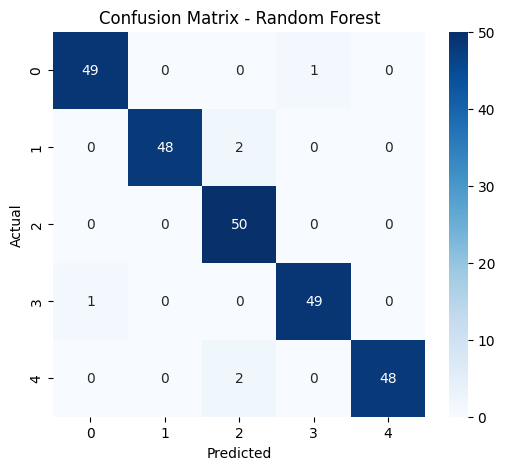

In [12]:
#Confusion Matrix (RF)

from sklearn.metrics import confusion_matrix
import seaborn as sns

rf.fit(X_train, y_train)

cm = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Explain classification performance

In [13]:
#Clasification report

from sklearn.metrics import classification_report

print(classification_report(y_test, rf.predict(X_test)))

#explain precision , recall, F1-score

              precision    recall  f1-score   support

      Banana       0.98      0.98      0.98        50
      Coffee       1.00      0.96      0.98        50
      Ginger       0.93      1.00      0.96        50
      Pepper       0.98      0.98      0.98        50
     Tapioca       1.00      0.96      0.98        50

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250



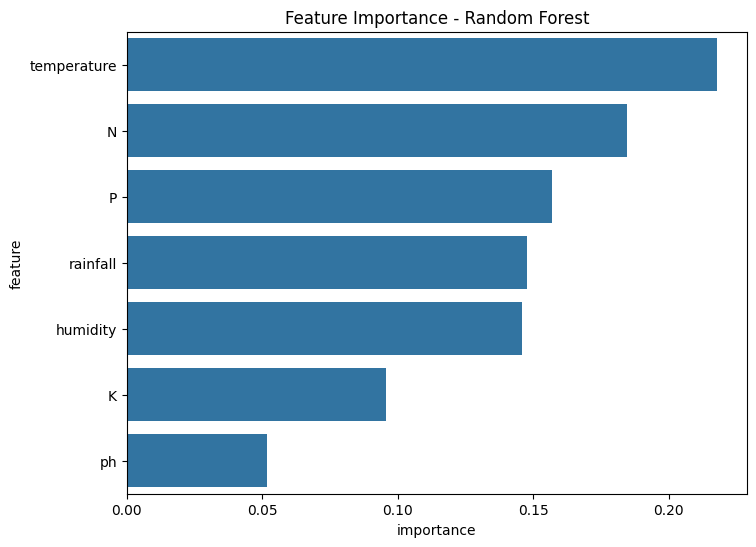

In [14]:
#Feature Importance

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=importance)
plt.title("Feature Importance - Random Forest")
plt.show()

#Feature Importance

In [15]:
#final modeling training

final_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

final_model.fit(X, y)

RandomForestClassifier(n_estimators=500, random_state=42)

In [17]:
#save as pkl


import pickle

with open("soil_dataset_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

In [20]:
#test loading pkl

with open("soil_dataset_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

loaded_model.predict(X.iloc[[0]])

array(['Banana'], dtype=object)

## Testing phase

In [21]:
#testing....

sample = X.iloc[[10]]   # take one real sample
actual_label = y.iloc[10]

prediction = final_model.predict(sample)

print("Actual:", actual_label)
print("Predicted:", prediction[0])

Actual: Banana
Predicted: Banana


In [22]:
for i in range(10):
    sample = X.iloc[[i]]
    print("Actual:", y.iloc[i],
          "| Predicted:", final_model.predict(sample)[0])

Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana
Actual: Banana | Predicted: Banana


In [23]:
sample = X.iloc[[10]]

probs = final_model.predict_proba(sample)[0]
classes = final_model.classes_

for crop, prob in zip(classes, probs):
    print(crop, ":", round(prob*100,2), "%")

Banana : 98.8 %
Coffee : 0.0 %
Ginger : 0.2 %
Pepper : 1.0 %
Tapioca : 0.0 %


In [24]:
test_input = sample.copy()

print("Original prediction:", final_model.predict(sample)[0])

test_input["rainfall"] += 50

print("After rainfall change:", final_model.predict(test_input)[0])

Original prediction: Banana
After rainfall change: Banana


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(final_model, X, y, cv=5)

print("Cross-validation mean:", scores.mean())

Cross-validation mean: 0.9591999999999998


In [26]:
import numpy as np
import pandas as pd

crops = df["label"].unique()

print("=== MODEL VALIDATION PER CROP ===\n")

for crop in crops:
    print(f"\n🔹 Testing Crop: {crop}")

    crop_samples = df[df["label"] == crop]

    # Take first 5 samples for testing
    for i in range(min(5, len(crop_samples))):
        sample = crop_samples.drop("label", axis=1).iloc[[i]]
        actual = crop_samples["label"].iloc[i]

        predicted = final_model.predict(sample)[0]
        probs = final_model.predict_proba(sample)[0]
        prob_dict = dict(zip(final_model.classes_, probs))

        print(f"Actual: {actual} | Predicted: {predicted} | Confidence: {round(prob_dict[predicted]*100,2)}%")

=== MODEL VALIDATION PER CROP ===


🔹 Testing Crop: Banana
Actual: Banana | Predicted: Banana | Confidence: 99.6%
Actual: Banana | Predicted: Banana | Confidence: 79.4%
Actual: Banana | Predicted: Banana | Confidence: 90.8%
Actual: Banana | Predicted: Banana | Confidence: 99.8%
Actual: Banana | Predicted: Banana | Confidence: 100.0%

🔹 Testing Crop: Coffee
Actual: Coffee | Predicted: Coffee | Confidence: 99.8%
Actual: Coffee | Predicted: Coffee | Confidence: 99.8%
Actual: Coffee | Predicted: Coffee | Confidence: 99.8%
Actual: Coffee | Predicted: Coffee | Confidence: 99.2%
Actual: Coffee | Predicted: Coffee | Confidence: 80.4%

🔹 Testing Crop: Ginger
Actual: Ginger | Predicted: Ginger | Confidence: 92.2%
Actual: Ginger | Predicted: Ginger | Confidence: 98.8%
Actual: Ginger | Predicted: Ginger | Confidence: 98.8%
Actual: Ginger | Predicted: Ginger | Confidence: 99.4%
Actual: Ginger | Predicted: Ginger | Confidence: 94.2%

🔹 Testing Crop: Pepper
Actual: Pepper | Predicted: Pepper | Confid

In [27]:
#Sensitivity Test
print("\n=== FEATURE SENSITIVITY TEST ===\n")

for crop in crops:
    print(f"\n🔹 Testing Variation for Crop: {crop}")

    crop_samples = df[df["label"] == crop]
    sample = crop_samples.drop("label", axis=1).iloc[[0]].copy()

    actual = crop_samples["label"].iloc[0]

    print("Original Prediction:", final_model.predict(sample)[0])

    # Increase rainfall
    sample_high = sample.copy()
    sample_high["rainfall"] += 50

    print("After Rainfall +50:", final_model.predict(sample_high)[0])

    # Decrease rainfall
    sample_low = sample.copy()
    sample_low["rainfall"] -= 50

    print("After Rainfall -50:", final_model.predict(sample_low)[0])


=== FEATURE SENSITIVITY TEST ===


🔹 Testing Variation for Crop: Banana
Original Prediction: Banana
After Rainfall +50: Banana
After Rainfall -50: Ginger

🔹 Testing Variation for Crop: Coffee
Original Prediction: Coffee
After Rainfall +50: Coffee
After Rainfall -50: Coffee

🔹 Testing Variation for Crop: Ginger
Original Prediction: Ginger
After Rainfall +50: Ginger
After Rainfall -50: Ginger

🔹 Testing Variation for Crop: Pepper
Original Prediction: Pepper
After Rainfall +50: Pepper
After Rainfall -50: Pepper

🔹 Testing Variation for Crop: Tapioca
Original Prediction: Tapioca
After Rainfall +50: Ginger
After Rainfall -50: Tapioca


In [28]:
for crop in crops:
    print(f"\n🔹 Extreme Variation for Crop: {crop}")

    crop_samples = df[df["label"] == crop]
    sample = crop_samples.drop("label", axis=1).iloc[[0]].copy()

    print("Original:", final_model.predict(sample)[0])

    for value in [50, 150, 300, 500]:
        test_sample = sample.copy()
        test_sample["rainfall"] = value
        print(f"Rainfall = {value} →", final_model.predict(test_sample)[0])


🔹 Extreme Variation for Crop: Banana
Original: Banana
Rainfall = 50 → Ginger
Rainfall = 150 → Ginger
Rainfall = 300 → Banana
Rainfall = 500 → Banana

🔹 Extreme Variation for Crop: Coffee
Original: Coffee
Rainfall = 50 → Coffee
Rainfall = 150 → Coffee
Rainfall = 300 → Coffee
Rainfall = 500 → Coffee

🔹 Extreme Variation for Crop: Ginger
Original: Ginger
Rainfall = 50 → Ginger
Rainfall = 150 → Ginger
Rainfall = 300 → Ginger
Rainfall = 500 → Ginger

🔹 Extreme Variation for Crop: Pepper
Original: Pepper
Rainfall = 50 → Ginger
Rainfall = 150 → Ginger
Rainfall = 300 → Pepper
Rainfall = 500 → Pepper

🔹 Extreme Variation for Crop: Tapioca
Original: Tapioca
Rainfall = 50 → Tapioca
Rainfall = 150 → Tapioca
Rainfall = 300 → Tapioca
Rainfall = 500 → Tapioca


In [29]:
#Plot Probability vs Rainfall Curve

import numpy as np
import matplotlib.pyplot as plt

# Take a Banana sample
sample = df[df["label"] == "Banana"].drop("label", axis=1).iloc[[0]].copy()

rain_values = np.linspace(0, 500, 100)

probabilities = []

for r in rain_values:
    temp_sample = sample.copy()
    temp_sample["rainfall"] = r

    prob = final_model.predict_proba(temp_sample)[0]
    probabilities.append(prob)

probabilities = np.array(probabilities)
classes = final_model.classes_

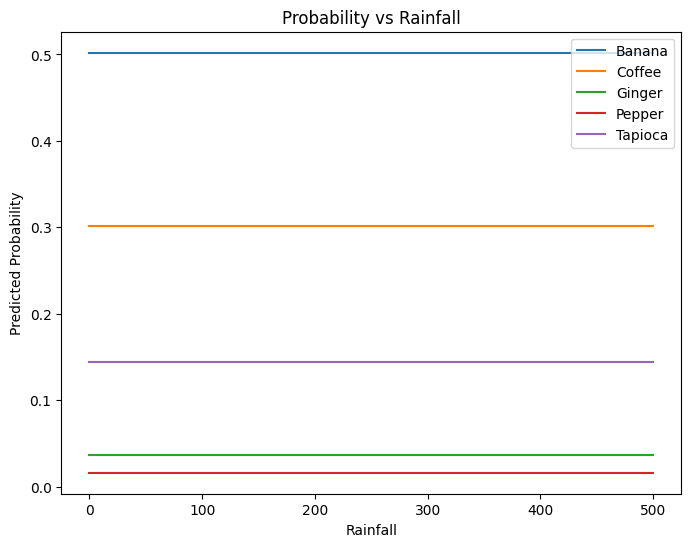

In [ ]:
plt.figure(figsize=(8,6))

for i, crop in enumerate(classes):
    plt.plot(rain_values, probabilities[:, i], label=crop)

plt.xlabel("Rainfall")
plt.ylabel("Predicted Probability")
plt.title("Probability vs Rainfall")
plt.legend()
plt.show()

Decision Boundary Visualization Using PCA

We reduce 7 features to 2 dimensions to visualize separation.

In [30]:
#Apply PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [31]:
#Train Model on PCA Data (for visualization only)

rf_pca = RandomForestClassifier(n_estimators=200, random_state=42)
rf_pca.fit(X_pca, y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [32]:
#create Meshgrid

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = rf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

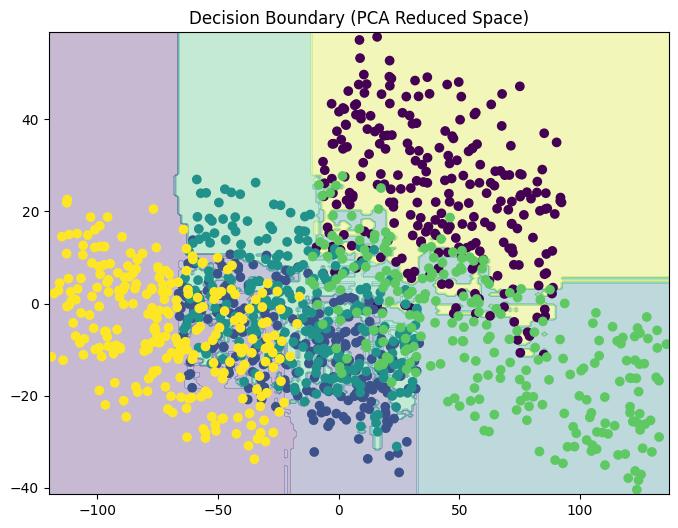

In [33]:
#ploa decision boundary

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, pd.factorize(Z.ravel())[0].reshape(xx.shape), alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(y)[0])
plt.title("Decision Boundary (PCA Reduced Space)")
plt.show()

Feature Response Curves (Partial Dependence)

This shows how model reacts to a feature.


Partial Dependence for: Banana


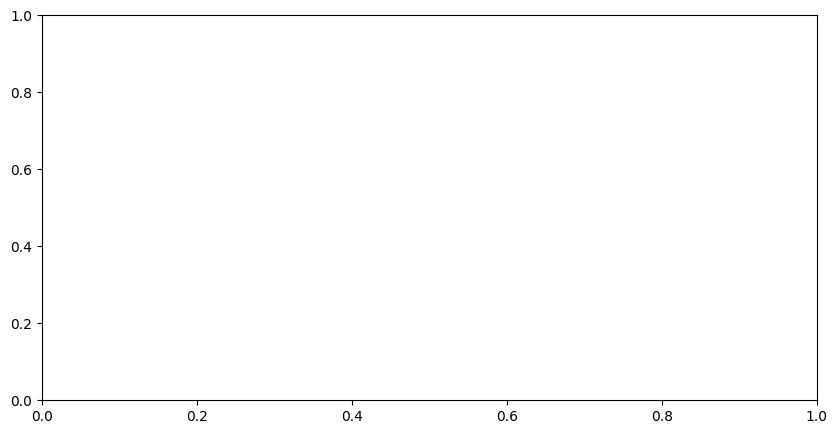

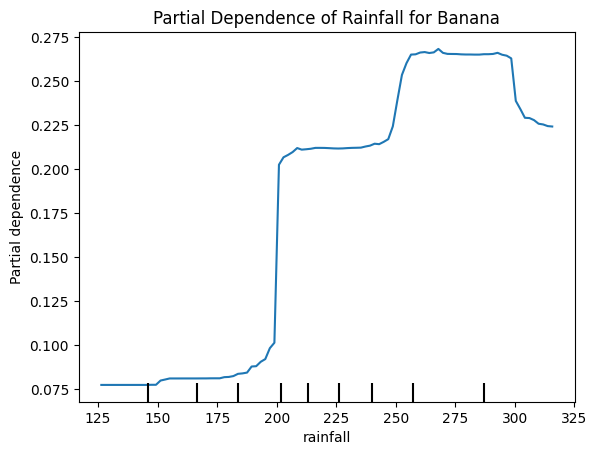


Partial Dependence for: Coffee


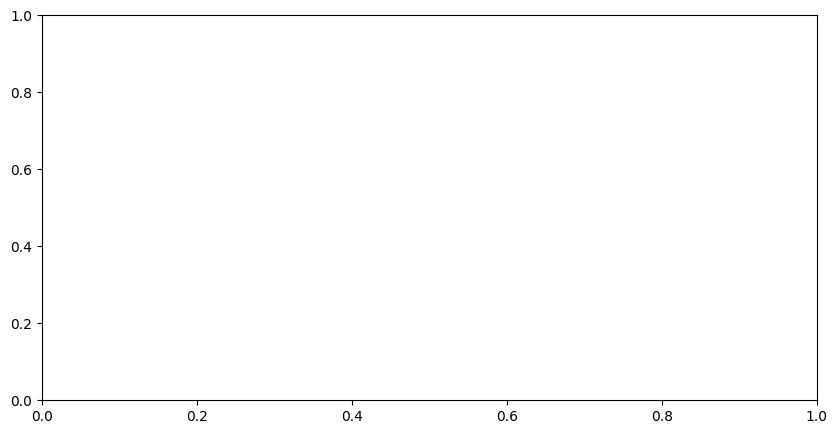

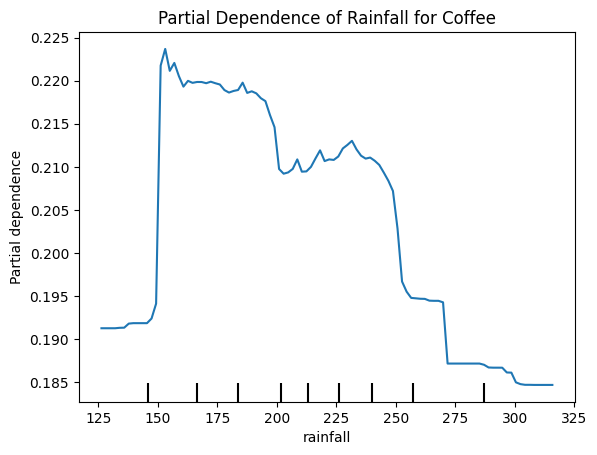


Partial Dependence for: Ginger


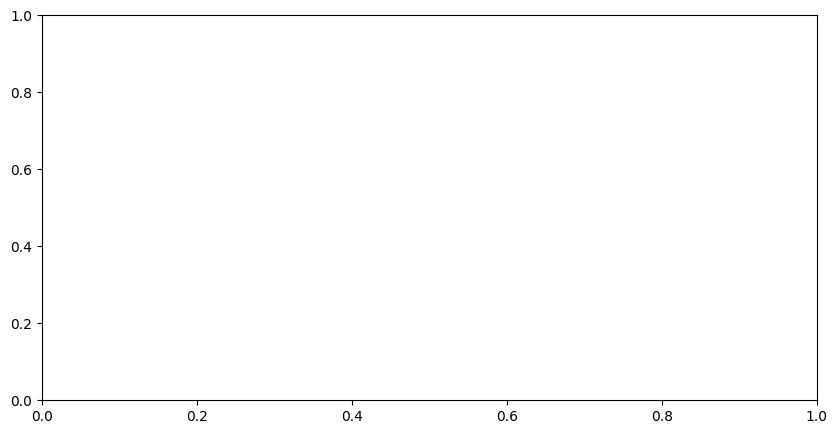

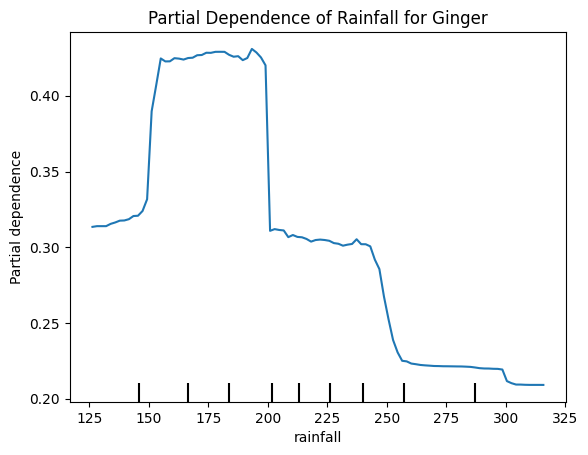


Partial Dependence for: Pepper


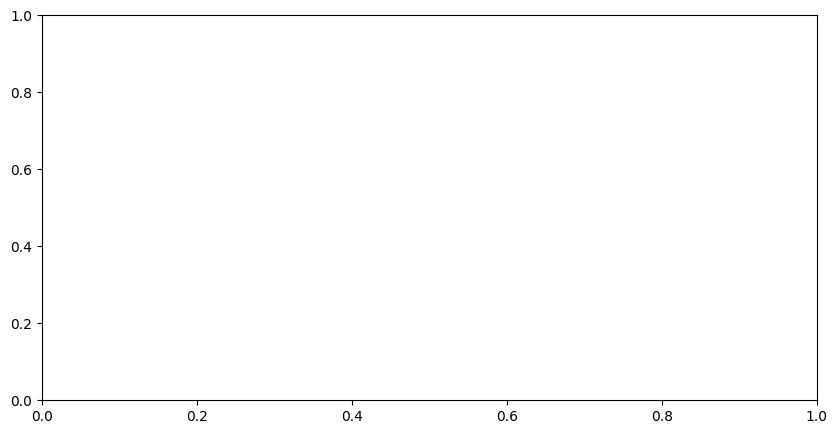

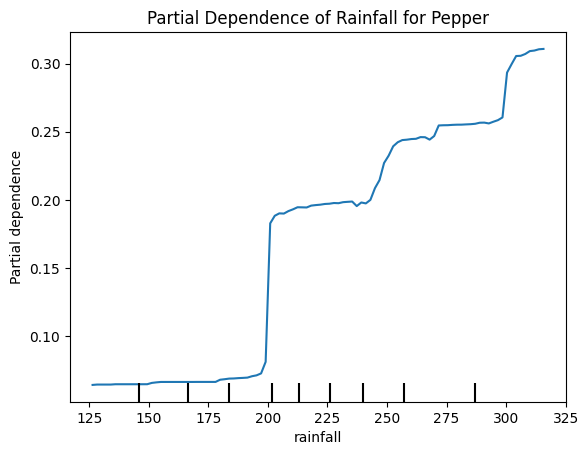


Partial Dependence for: Tapioca


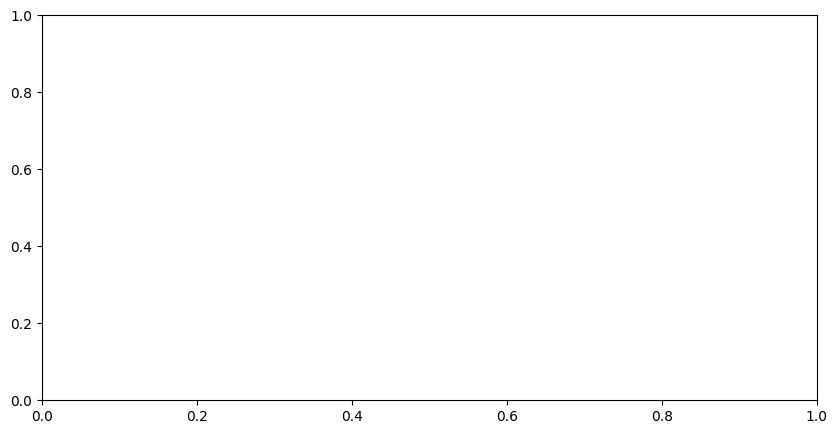

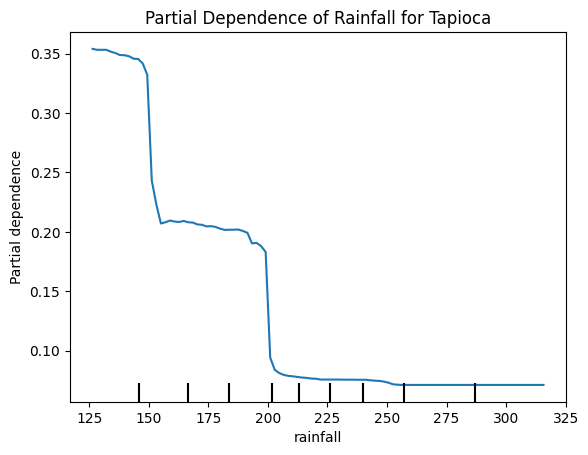

In [34]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

for crop in final_model.classes_:
    print(f"\nPartial Dependence for: {crop}")

    fig, ax = plt.subplots(figsize=(10, 5))

    PartialDependenceDisplay.from_estimator(
        final_model,
        X,
        features=["rainfall"],
        target=crop
    )

    plt.title(f"Partial Dependence of Rainfall for {crop}")
    plt.show()

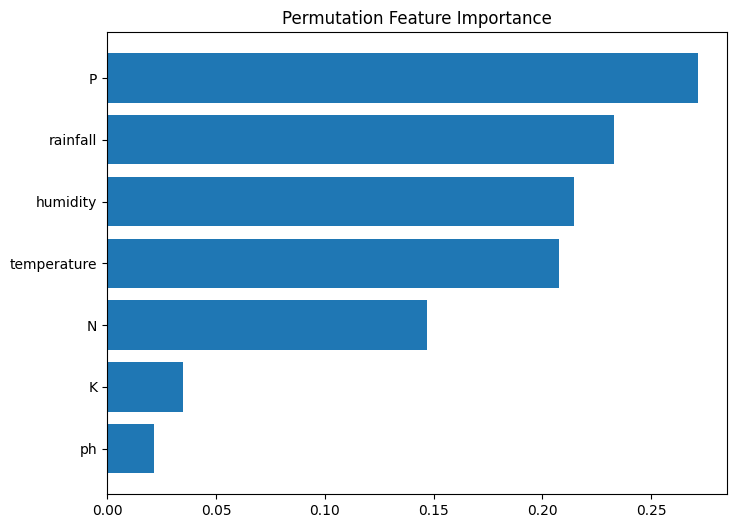

In [35]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    final_model,
    X,
    y,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(perm_importance["feature"], perm_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.show()